# Phase 1: การเตรียมข้อมูล (Data Preprocessing)
ส่วนนี้แสดงกระบวนการนำเข้าชุดข้อมูล (Data Import) การจัดเตรียมโครงสร้างข้อมูล และการสร้างตัวแปรเป้าหมาย (Target Variable: `risk_level`) ด้วยระบบประเมินคะแนนความเสี่ยง (Risk Scoring)

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ตั้งค่าฟอนต์ภาษาไทยสำหรับกราฟ
plt.rcParams['font.family'] = 'Tahoma'

# 1. การนำเข้าข้อมูล
df = pd.read_csv('income_expense_behavior_vs_cost_of_living_crisis.csv')
print(f'ขนาดของข้อมูลเริ่มต้น: {df.shape}')
df.head(2)

ขนาดของข้อมูลเริ่มต้น: (300, 20)


,Timestamp,ความยินยอมในการใช้ข้อมูลส่วนบุคคล,1. เพศของท่าน,2. ช่วงอายุเเละช่วงวัย,3. สถานะการทำงานของท่าน,4. รายได้สุทธิเฉลี่ยต่อเดือน (หลังหักภาษี),5. จำนวนสมาชิกในครอบครัวที่อยู่ในความดูเเลรับผิดชอบด้านค่าใช้จ่าย (รวมตัวท่าน),6. ภาระหนี้สินคงที่ต่อเดือน,7. ค่าใช้จ่ายด้านน้ำมันเเละการเดินทางเฉลี่ยต่อเดือน (บาท),8. จำนวนผลิตภัณฑ์บัตรเครดิตหรือวงเงินสินเชื่อหมุนเวียนที่ถือครอง,9. ลักษณะการชำระหนี้บัตรเครดิตในรอบ 6 เดือนที่ผ่านมา,10. ความถี่ในการเลือกซื้อสินค้าตามความพึงพอใจ โดยไม่ได้วางเเผน,11. การถือครองทรัพย์สินหรือการลงทุน,12. สภาพคล่องคงเหลือ (กรณีรายได้หยุด ชะงัก ท่านมีเงินสำรองอยู่ได้กี่เดือน?),"13. ในรอบ 1 ปีที่ผ่านมา ท่านเคยประสบสภาวะ ""หมุนเงินไม่ทัน"" จนต้องหยิบยืมเงินหรือไม่",14. หากเกิดเหตุฉุกเฉินที่ต้องใช้เงินก้อนทันที ท่านมีเเหล่งเงินทุนรองรับหรือไม่,15. ท่านมีความกังวลต่อสถานะทางการเงินของตนเองในปัจจุบันระดับใด,16. หากราคาน้ำมันเเละค่าครองชีพสูงขึ้น ร้อยละ 20 ท่านจะให้ความสำคัญกับการดำเนินการสิ่งใดมากที่สุด,17. ท่านมีความรู้ความเข้าใจด้านการวางเเผนการเงินเเละภาษี,18. ท่านมีสวัสดิการหรือประกันสุขภาพส่วนบุคคลที่เพียงพอต่อความเสี่ยง ในรูปแบบใดบ้าง
0,2026/05/04 3:29:16 PM GMT+7,รับทราบเเละยินยอม,ชาย,Gen Z (เกิดปี พ.ศ. 2541 - 2555 / อายุ 14 - 28 ปี),นักเรียน/นักศึกษา,"ต่ำกว่า 10,000 บาท",4 ท่าน,ไม่มีภาระหนี้สิน,1000,ไม่มีบัตรเครดิตหรือวงเงินสินเชื่อ,ไม่มีบัตรเครดิต,4,มีน้อยกว่า 100 % ของรายได้,3 - 6 เดือน,ไม่เคย,มีเงินเก็บส่วนตัวเพียงพอ,2,เเสวงหารายได้เสริม,4,สวัสดิการพื้นฐานจากภาครัฐ (เช่น สิทธิบัตรทอง 3...
1,2026/05/04 3:30:16 PM GMT+7,รับทราบเเละยินยอม,หญิง,Gen Z (เกิดปี พ.ศ. 2541 - 2555 / อายุ 14 - 28 ปี),ธุรกิจส่วนตัว / ค้าขาย / ฟรีแลนซ์,"10,001 - 25,000 บาท",5 ท่านขึ้นไป,ร้อยละ 31 - 50 ของรายได้,2000,ไม่มีบัตรเครดิตหรือวงเงินสินเชื่อ,ไม่มีบัตรเครดิต,3,ไม่มีการถือครอง,น้อยกว่า 1 เดือน,1 - 2 ครั้งต่อปี,ขอความช่วยเหลือทางการเงินจากครอบครัว/ญาติ,4,ปรับลดค่าใช้จ่ายที่จำเป็น,3,สวัสดิการพื้นฐานจากภาครัฐ (เช่น สิทธิบัตรทอง 3...


In [46]:
# 2. การเปลี่ยนชื่อตัวแปรให้เป็นภาษาอังกฤษ
column_mapping = {
    "1. เพศของท่าน": "sex",
    "2. ช่วงอายุเเละช่วงวัย": "age_group",
    "3. สถานะการทำงานของท่าน": "occupation",
    "4. รายได้สุทธิเฉลี่ยต่อเดือน (หลังหักภาษี)": "income",
    "5. จำนวนสมาชิกในครอบครัวที่อยู่ในความดูเเลรับผิดชอบด้านค่าใช้จ่าย (รวมตัวท่าน) ": "family_size",
    "6. ภาระหนี้สินคงที่ต่อเดือน": "debt",
    "7. ค่าใช้จ่ายด้านน้ำมันเเละการเดินทางเฉลี่ยต่อเดือน (บาท)": "travel_cost",
    "8. จำนวนผลิตภัณฑ์บัตรเครดิตหรือวงเงินสินเชื่อหมุนเวียนที่ถือครอง": "credit_cards",
    "9. ลักษณะการชำระหนี้บัตรเครดิตในรอบ 6 เดือนที่ผ่านมา": "payment_behavior",
    " 10. ความถี่ในการเลือกซื้อสินค้าตามความพึงพอใจ โดยไม่ได้วางเเผน": "impulse_buying",
    "11. การถือครองทรัพย์สินหรือการลงทุน ": "assets",
    "12. สภาพคล่องคงเหลือ (กรณีรายได้หยุด ชะงัก ท่านมีเงินสำรองอยู่ได้กี่เดือน?)": "liquidity",
    "13. ในรอบ 1 ปีที่ผ่านมา ท่านเคยประสบสภาวะ \"หมุนเงินไม่ทัน\" จนต้องหยิบยืมเงินหรือไม่": "shortage",
    "14. หากเกิดเหตุฉุกเฉินที่ต้องใช้เงินก้อนทันที ท่านมีเเหล่งเงินทุนรองรับหรือไม่": "emergency_fund",
    "15. ท่านมีความกังวลต่อสถานะทางการเงินของตนเองในปัจจุบันระดับใด": "concern_level",
    "16. หากราคาน้ำมันเเละค่าครองชีพสูงขึ้น ร้อยละ 20 ท่านจะให้ความสำคัญกับการดำเนินการสิ่งใดมากที่สุด": "coping_strategy",
    "17. ท่านมีความรู้ความเข้าใจด้านการวางเเผนการเงินเเละภาษี": "financial_literacy",
    "18. ท่านมีสวัสดิการหรือประกันสุขภาพส่วนบุคคลที่เพียงพอต่อความเสี่ยง ในรูปแบบใดบ้าง ": "welfare"
}
df = df.rename(columns=column_mapping)
print("เปลี่ยนชื่อคอลัมน์เรียบร้อยแล้ว")

เปลี่ยนชื่อคอลัมน์เรียบร้อยแล้ว


In [47]:
# การจัดกลุ่มข้อมูลอายุ (Generation) และรายได้
age_map = {
    'Gen Z (เกิดปี พ.ศ. 2541 - 2555 / อายุ 14 - 28 ปี)': 'Gen Z',
    'Gen Y / Millennials (เกิดปี พ.ศ. 2523 - 2540 / อายุ 29 - 46 ปี)': 'Gen Y',
    'Gen X (เกิดปี พ.ศ. 2508 - 2522 / อายุ 47 - 61 ปี)': 'Gen X'
}
df['age_group'] = df['age_group'].map(age_map)

income_map = {
    'ต่ำกว่า 10,000 บาท': 5000,
    '10,001 - 25,000 บาท': 17500,
    '25,001 - 50,000 บาท': 37500,
    'มากกว่า 50,000 บาท': 75000
}
df['income_num'] = df['income'].map(income_map)

# การจัดการค่าสูญหาย (Missing Values) ด้วยค่ามัธยฐาน (Median)
df['travel_cost'] = pd.to_numeric(df['travel_cost'], errors='coerce')
df['travel_cost'].fillna(df['travel_cost'].median(), inplace=True)

# สร้างฟีเจอร์ใหม่: อัตราส่วนหนี้สินต่อรายได้ (Debt-to-Income Ratio)
# โดยแปลงจากข้อความให้เป็นตัวเลขเปอร์เซ็นต์กลางๆ เพื่อให้โมเดลคำนวณได้
debt_ratio_map = {
    'ไม่มีภาระหนี้สิน': 0.0,
    'ต่ำกว่าร้อยละ 30 ของรายได้': 0.15,
    'ร้อยละ 31 - 50 ของรายได้': 0.40,
    'มากกว่าร้อยละ 50 ของรายได้': 0.60
}
df['debt_to_income_ratio'] = df['debt'].map(debt_ratio_map)

/var/folders/_t/qb0xv13s1hj8zgt9f6lydk3c0000gn/T/ipykernel_55135/2695997946.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['travel_cost'].fillna(df['travel_cost'].median(), inplace=True)


In [48]:
# 3. การคำนวณคะแนนความเสี่ยงเพื่อสร้างตัวแปรเป้าหมาย (Target Variable)

liq_score_map = {
    'น้อยกว่า 1 เดือน': 3,
    '1 - 3 เดือน': 2,
    '3 - 6 เดือน': 1,
    'มากกว่า 6 เดือน': 0
}
short_score_map = {
    'มากกว่า 2 ครั้ง': 3,
    '1 - 2 ครั้งต่อปี': 2,
    'ไม่เคย': 0
}
debt_score_map = {
    'มากกว่าร้อยละ 50 ของรายได้': 3,
    'ร้อยละ 31 - 50 ของรายได้': 2,
    'ต่ำกว่าร้อยละ 30 ของรายได้': 1,
    'ไม่มีภาระหนี้สิน': 0
}

df['liquidity_score'] = df['liquidity'].map(liq_score_map)
df['shortage_score'] = df['shortage'].map(short_score_map)
df['debt_score'] = df['debt'].map(debt_score_map)

# คำนวณคะแนนรวม (เต็ม 9)
df['total_risk_score'] = df['liquidity_score'] + df['shortage_score'] + df['debt_score']

# ตัดเกรดความเสี่ยง
def calculate_risk(score):
    if score >= 6:
        return 'High Risk'
    elif score >= 3:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df['risk_level'] = df['total_risk_score'].apply(calculate_risk)

print('สรุปจำนวนตัวอย่างในแต่ละกลุ่มความเสี่ยง:')
print(df['risk_level'].value_counts())


สรุปจำนวนตัวอย่างในแต่ละกลุ่มความเสี่ยง:
risk_level
High Risk      114
Low Risk       104
Medium Risk     82
Name: count, dtype: int64


---
# Phase 2: การวิเคราะห์ Insight และการแสดงผล (EDA & Visualization)
ส่วนนี้เป็นการสร้างการสร้างแผนภาพข้อมูล (Data Visualization) เพื่อค้นหาความสัมพันธ์ของตัวแปรต่างๆ

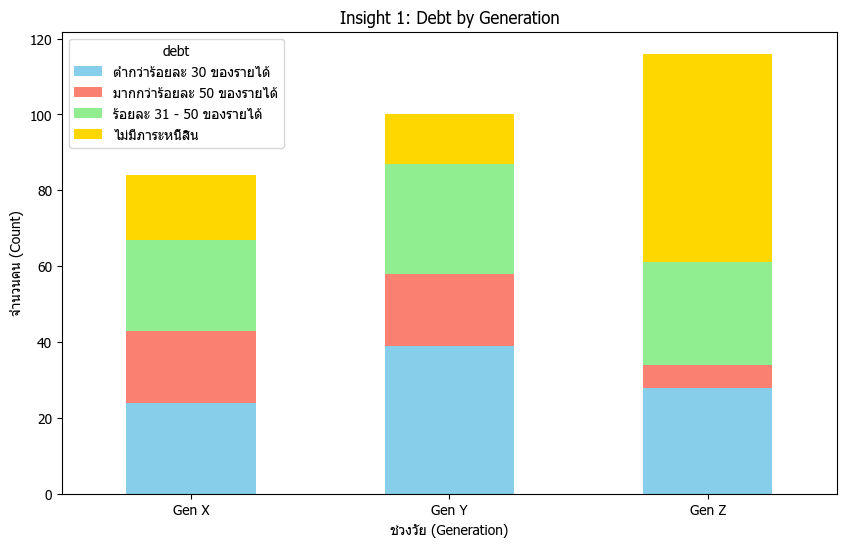

In [49]:
# ---------------------------------------------------------
# Insight 1: ใครคือหนี้ก้อนใหญ่? (Debt by Generation)
# ---------------------------------------------------------

# การจัดกลุ่มข้อมูลเพื่อหาความถี่
debt_gen = df.groupby(['age_group', 'debt']).size().unstack()

debt_gen.plot(kind='bar', stacked=True, figsize=(10,6), color=['skyblue', 'salmon', 'lightgreen', 'gold', 'orchid'])
plt.title('Insight 1: Debt by Generation')
plt.ylabel('จำนวนคน (Count)')
plt.xlabel('ช่วงวัย (Generation)')
plt.xticks(rotation=0)
plt.show()

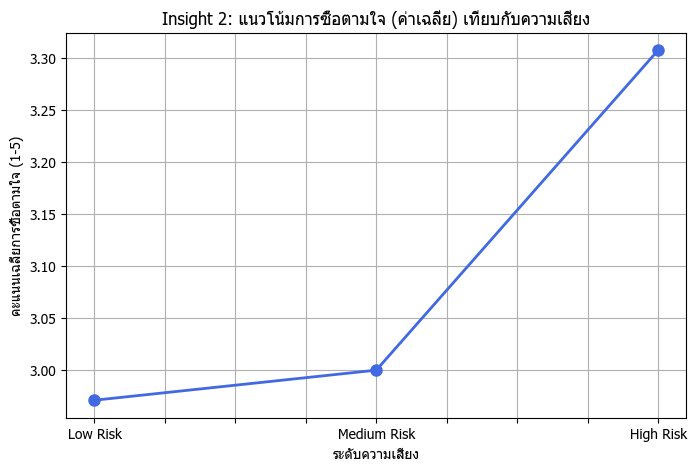

In [50]:
# ---------------------------------------------------------
# Insight 2: กับดักความสุขชั่วคราว (Impulse Buying vs. Risk Level)
# สไตล์: กราฟเส้น (Line Chart) ดูแนวโน้มค่าเฉลี่ย
# ---------------------------------------------------------

# การจัดเรียงลำดับกลุ่มความเสี่ยง
risk_order = ['Low Risk', 'Medium Risk', 'High Risk']

# หาค่าเฉลี่ยของการซื้อตามใจในแต่ละกลุ่มความเสี่ยง
impulse_avg = df.groupby('risk_level')['impulse_buying'].mean().reindex(risk_order)

# พล็อตกราฟเส้น ใส่จุด (marker) ให้ดูชัดเจน
impulse_avg.plot(kind='line', marker='o', color='royalblue', linewidth=2, markersize=8, figsize=(8,5))
plt.title('Insight 2: แนวโน้มการซื้อตามใจ (ค่าเฉลี่ย) เทียบกับความเสี่ยง')
plt.xlabel('ระดับความเสี่ยง')
plt.ylabel('คะแนนเฉลี่ยการซื้อตามใจ (1-5)')
plt.grid(True)
plt.show()

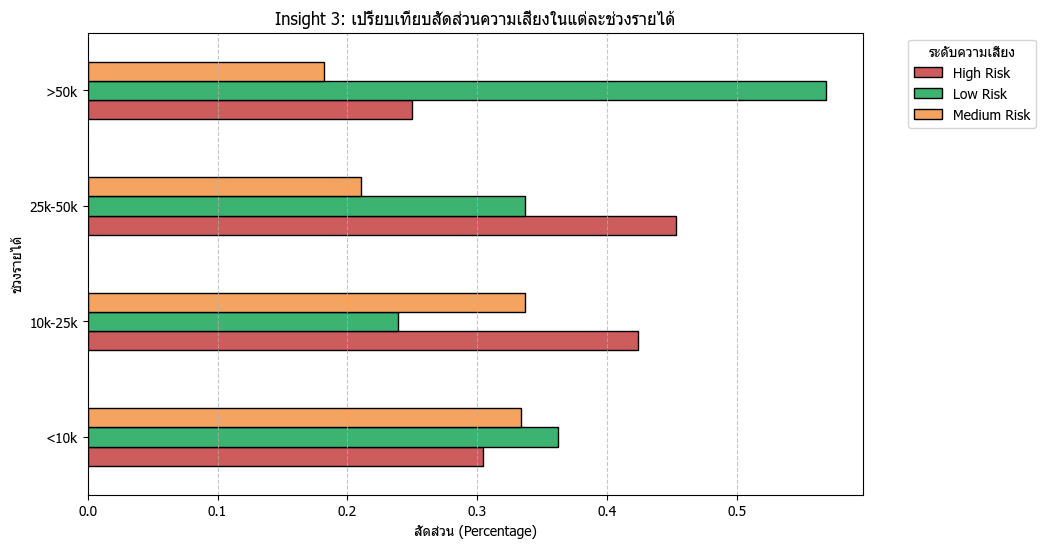

In [51]:
# ---------------------------------------------------------
# Insight 3: เงินเดือนเยอะแปลว่ารอดจริงหรือ? (Income vs. Risk Level)
# สไตล์: กราฟแท่งแนวนอน (Horizontal Bar Chart)
# ---------------------------------------------------------

# การจัดกลุ่มช่วงรายได้
income_labels = {
    5000: '<10k',
    17500: '10k-25k',
    37500: '25k-50k',
    75000: '>50k'
}
df['income_label'] = df['income_num'].map(income_labels)
income_order = ['<10k', '10k-25k', '25k-50k', '>50k']

# 1. นับจำนวนคนแยกตาม รายได้ และ ความเสี่ยง
income_risk_count = df.groupby(['income_label', 'risk_level']).size().unstack()

# 2. แปลงเป็นเปอร์เซ็นต์ (หารด้วยผลรวมของแต่ละแถว)
income_risk_percent = income_risk_count.div(income_risk_count.sum(axis=1), axis=0)

# 3. เรียงลำดับช่วงรายได้ให้ถูกต้อง
income_risk_percent = income_risk_percent.reindex(income_order)

colors = {'Low Risk': 'mediumseagreen', 'Medium Risk': 'sandybrown', 'High Risk': 'indianred'}
# ปรับเป็นกราฟแนวนอน (barh) และไม่ stack (stacked=False) 
# เพิ่มขอบสีดำ (edgecolor) และเส้นตาราง (grid) แบบพื้นฐาน
income_risk_percent.plot(kind='barh', stacked=False, color=[colors[c] for c in income_risk_percent.columns], 
                         figsize=(10,6), edgecolor='black')
plt.title('Insight 3: เปรียบเทียบสัดส่วนความเสี่ยงในแต่ละช่วงรายได้')
plt.xlabel('สัดส่วน (Percentage)')
plt.ylabel('ช่วงรายได้')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.legend(title='ระดับความเสี่ยง', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

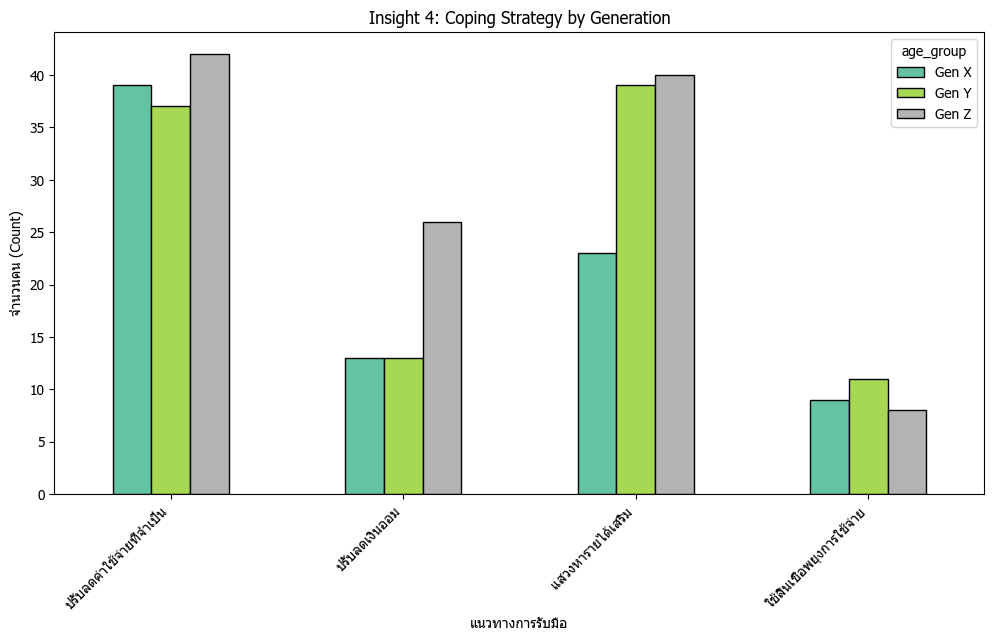

In [52]:
# ---------------------------------------------------------
# Insight 4: แผนรับมือเมื่อวิกฤตมาเยือน (Coping Strategy by Gen)
# สไตล์: กราฟแท่งจัดกลุ่ม (Grouped Bar Chart)
# ---------------------------------------------------------

coping_gen = df.groupby(['coping_strategy', 'age_group']).size().unstack()

coping_gen.plot(kind='bar', figsize=(12,6), colormap='Set2', edgecolor='black')
plt.title('Insight 4: Coping Strategy by Generation')
plt.xlabel('แนวทางการรับมือ')
plt.ylabel('จำนวนคน (Count)')
plt.xticks(rotation=45, ha='right')
plt.show()

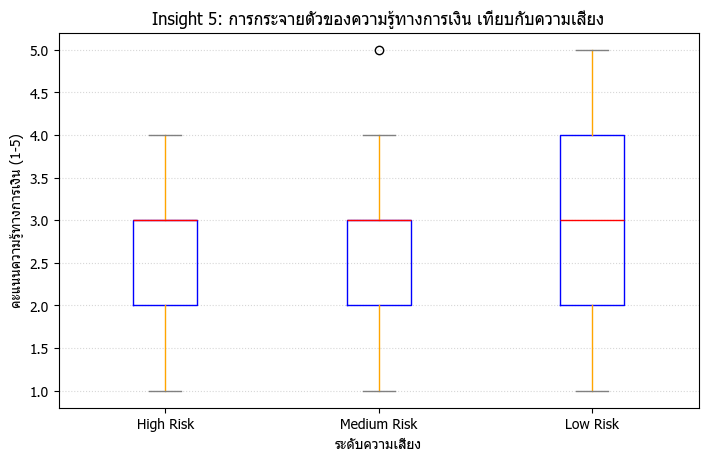

In [53]:
# ---------------------------------------------------------
# Insight 5: ความรู้คือภูมิคุ้มกันชั้นดี? (Financial Literacy vs. Risk Level)
# สไตล์: Boxplot ดูการกระจายตัวของความรู้ทางการเงินในแต่ละกลุ่มความเสี่ยง
# ---------------------------------------------------------

# การจัดเรียงลำดับกลุ่มความเสี่ยงสำหรับการแสดงผล
df['risk_level'] = pd.Categorical(df['risk_level'], categories=['High Risk', 'Medium Risk', 'Low Risk'], ordered=True)

# ใช้คำสั่งพื้นฐานของ pandas ในการทำ Boxplot
# ปรับแต่งสีของกล่องและเส้นให้ดูดีขึ้นด้วยพารามิเตอร์พื้นฐาน (color props)
# Boxes=น้ำเงิน, Whiskers=ส้ม, Medians=แดง
props = dict(boxes="blue", whiskers="orange", medians="red", caps="gray")
df.boxplot(column='financial_literacy', by='risk_level', grid=False, figsize=(8,5), color=props)

plt.title('Insight 5: การกระจายตัวของความรู้ทางการเงิน เทียบกับความเสี่ยง')
plt.suptitle('') # ลบ title อัตโนมัติของ pandas ทิ้งให้กราฟดูสะอาด
plt.xlabel('ระดับความเสี่ยง')
plt.ylabel('คะแนนความรู้ทางการเงิน (1-5)')
plt.grid(axis='y', linestyle=':', alpha=0.5) # เพิ่มเส้นตารางบางๆ แนวนอน
plt.show()

---
# Phase 3: การพัฒนาและทดสอบโมเดล (Machine Learning)
ส่วนนี้แสดงกระบวนการพัฒนาและทดสอบแบบจำลอง (Model Training and Evaluation) เพื่อจำแนกกลุ่มความเสี่ยงทางการเงิน

**ขั้นตอนที่ 1: การเตรียมข้อมูลให้คอมพิวเตอร์เข้าใจ (Data Encoding)**
คอมพิวเตอร์ไม่รู้จักคำว่า "ไม่มีบัตรเครดิต" เราต้องแปลงคำตอบเหล่านี้เป็น **"ตัวเลข"** ให้หมดก่อน

In [54]:
# การแปลงข้อมูลเชิงคุณภาพให้เป็นข้อมูลเชิงปริมาณ
payment_map = {
    'ไม่มีบัตรเครดิต': 0,      'ชำระเต็มจำนวน': 0,
    'ชำระขั้นต่ำบางส่วน': 2,   'ชำระขั้นต่ำทุกงวด': 3,
    'ค้างชำระ': 4
}
credit_map = {
    'ไม่มีบัตรเครดิตหรือวงเงินสินเชื่อ': 0,
    '1 - 2 ใบ': 1, '3 - 4 ใบ': 2, '5 ใบขึ้นไป': 3
}
assets_map = {
    'ไม่มีการถือครอง': 3,
    'มีน้อยกว่า 100 % ของรายได้': 2,
    'มี 100% - 500% ของรายได้': 1,
    'มี 501% - 1,200% ของรายได้': 0,
    'มีมากกว่า 1,200% ของรายได้': 0
}
emergency_map = {
    'มีเงินเก็บส่วนตัวเพียงพอ': 0,
    'ขอความช่วยเหลือทางการเงินจากครอบครัว/ญาติ': 1,
    'ใช้บัตรเครดิต / กดเงินสด / กู้ยืมสินเชื่อในระบบ': 2,
    'หยิบยืมจากเพื่อนหรือคนรู้จัก': 3,
    'กู้ยืมเงินจากแหล่งนอกระบบ': 4
}
family_map = {
    '1 ท่าน (ดูเเลตนเองเพียงลำพัง)': 1,
    '2 ท่าน': 2, '3 ท่าน': 3, '4 ท่าน': 4, '5 ท่านขึ้นไป': 5
}

df['payment_score']   = df['payment_behavior'].map(payment_map)
df['credit_score']    = df['credit_cards'].map(credit_map)
df['assets_score']    = df['assets'].map(assets_map)
df['emergency_score'] = df['emergency_fund'].map(emergency_map)
df['family_num']      = df['family_size'].map(family_map)

# การกำหนดตัวแปรอิสระ (Features / X)
features = [
    'income_num', 'debt_score', 'liquidity_score', 'shortage_score',
    'payment_score', 'credit_score', 'assets_score', 'emergency_score',
    'impulse_buying', 'concern_level', 'financial_literacy',
    'travel_cost', 'family_num'
]

# การแปลงตัวแปรเป้าหมาย (Target Variable / y) เป็นค่าตัวเลข
risk_encode = {'Low Risk': 0, 'Medium Risk': 1, 'High Risk': 2}
df['risk_code'] = df['risk_level'].map(risk_encode)

X = df[features]
y = df['risk_code']

print("การจัดเตรียมชุดข้อมูล X และ y เสร็จสมบูรณ์")

การจัดเตรียมชุดข้อมูล X และ y เสร็จสมบูรณ์


**ขั้นตอนที่ 2: แบ่งข้อมูลสำหรับการสอน (Train) และการสอบ (Test)**
เก็บข้อมูล 20% ไว้เป็น "ข้อสอบลับ" เพื่อวัดว่าคอมพิวเตอร์เก่งจริงไหม

In [55]:
from sklearn.model_selection import train_test_split

# การแบ่งชุดข้อมูล (Training Set 80% และ Testing Set 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"ขนาดของชุดข้อมูลฝึกสอน (Training Set): {len(X_train)} คน")
print(f"ขนาดของชุดข้อมูลทดสอบ (Testing Set): {len(X_test)} คน")

ขนาดของชุดข้อมูลฝึกสอน (Training Set): 240 คน
ขนาดของชุดข้อมูลทดสอบ (Testing Set): 60 คน


**ขั้นตอนที่ 3: ฝึกสอนโมเดลที่ 1 (Logistic Regression)**
แบบจำลอง Logistic Regression ถูกนำมาใช้ในการวิเคราะห์ความน่าจะเป็นที่บุคคลจะตกอยู่ในกลุ่มความเสี่ยงระดับต่างๆ

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# การสร้างแบบจำลอง Logistic Regression
model_lr = LogisticRegression(max_iter=1000, random_state=42)

# การฝึกสอนแบบจำลอง (Model Training)
model_lr.fit(X_train, y_train)

# การทำนายผลลัพธ์จากชุดข้อมูลทดสอบ (Model Prediction)
y_pred_lr = model_lr.predict(X_test)

# การประเมินความแม่นยำของแบบจำลอง (Accuracy Score)
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"ระดับความแม่นยำ (Accuracy) ของ Logistic Regression: {acc_lr*100:.2f}%")

# การแสดงผลการประเมินแบบจำลองโดยละเอียด
print("\nรายงานการประเมินการจำแนกประเภท (Classification Report):")
print(classification_report(y_test, y_pred_lr, target_names=['Low Risk', 'Medium Risk', 'High Risk']))


ระดับความแม่นยำ (Accuracy) ของ Logistic Regression: 86.67%

รายงานการประเมินการจำแนกประเภท (Classification Report):
              precision    recall  f1-score   support

    Low Risk       0.95      0.87      0.91        23
 Medium Risk       0.74      0.82      0.78        17
   High Risk       0.90      0.90      0.90        20

    accuracy                           0.87        60
   macro avg       0.86      0.86      0.86        60
weighted avg       0.87      0.87      0.87        60



/Users/chayanon/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/chayanon/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/chayanon/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/chayanon/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/Users/chayanon/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_

**ขั้นตอนที่ 3.1: การสร้างและแสดงผล Confusion Matrix สำหรับ Logistic Regression**
Confusion Matrix คือตารางที่ใช้สรุปผลการทำนายของโมเดล Classification โดยเฉพาะ มันจะช่วยให้เราเห็นภาพว่าโมเดลของเรา **ทายถูก** และ **ทายผิด** อย่างไรบ้างในแต่ละคลาส

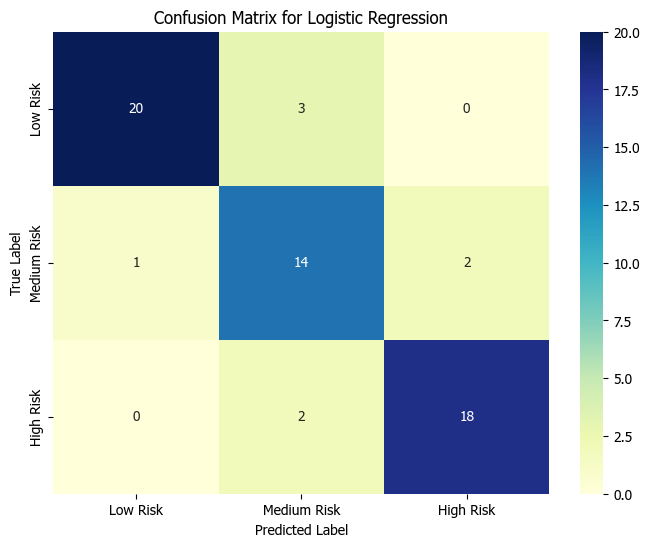

In [57]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# สร้าง Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
labels = ['Low Risk', 'Medium Risk', 'High Risk']

# พล็อตกราฟ Heatmap ด้วย Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='YlGnBu', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

**ขั้นตอนที่ 4: ฝึกสอนโมเดลที่ 2 (K-Nearest Neighbors - KNN)**
แบบจำลอง K-Nearest Neighbors (KNN) จะทำการจำแนกกลุ่มความเสี่ยงโดยพิจารณาจากความคล้ายคลึงของพฤติกรรมเทียบกับจุดข้อมูลที่ใกล้ที่สุด

In [58]:
from sklearn.neighbors import KNeighborsClassifier

# เนื่องจาก KNN วัดระยะทางจากตัวเลข เราควรปรับสเกลตัวเลขให้พอๆ กันก่อน (Standardization)
# เช่น รายได้ 50,000 กับ จำนวนคนในบ้าน 4 คน ตัวเลขมันต่างกันเยอะมาก
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# การสร้างแบบจำลอง K-Nearest Neighbors
model_knn = KNeighborsClassifier(n_neighbors=5)

# การฝึกสอนแบบจำลอง (Model Training)
model_knn.fit(X_train_scaled, y_train)

# การทำนายผลลัพธ์จากชุดข้อมูลทดสอบ (Model Prediction)
y_pred_knn = model_knn.predict(X_test_scaled)

# การประเมินความแม่นยำของแบบจำลอง (Accuracy Score)
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"ระดับความแม่นยำ (Accuracy) ของ K-Nearest Neighbors (KNN): {acc_knn*100:.2f}%")

# การแสดงผลการประเมินแบบจำลองโดยละเอียด
print("\nรายงานการประเมินการจำแนกประเภท (Classification Report):")
print(classification_report(y_test, y_pred_knn, target_names=['Low Risk', 'Medium Risk', 'High Risk']))


ระดับความแม่นยำ (Accuracy) ของ K-Nearest Neighbors (KNN): 78.33%

รายงานการประเมินการจำแนกประเภท (Classification Report):
              precision    recall  f1-score   support

    Low Risk       0.75      0.91      0.82        23
 Medium Risk       0.67      0.47      0.55        17
   High Risk       0.90      0.90      0.90        20

    accuracy                           0.78        60
   macro avg       0.77      0.76      0.76        60
weighted avg       0.78      0.78      0.77        60



**ขั้นตอนที่ 4.1: การสร้างและแสดงผล Confusion Matrix สำหรับ K-Nearest Neighbors (KNN)**
เรามาดูตาราง Confusion Matrix สำหรับโมเดล KNN กันบ้าง เพื่อเปรียบเทียบว่าโมเดลนี้มีการทำนายที่แตกต่างจาก Logistic Regression อย่างไร และมีข้อผิดพลาดในคลาสใดบ้าง

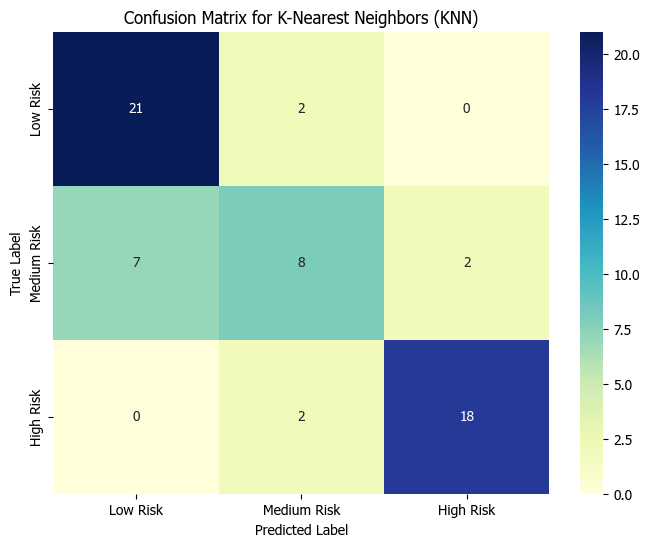

In [59]:
# สร้าง Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
labels = ['Low Risk', 'Medium Risk', 'High Risk']

# พล็อตกราฟ Heatmap ด้วย Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='YlGnBu', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix for K-Nearest Neighbors (KNN)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

---
# Phase 4: การนำไปใช้และสรุปผล (Deployment & Recommendations)
ส่วนนี้แสดงผลการสกัดคุณลักษณะที่สำคัญ (Feature Importance) และจำลองระบบประเมินความเสี่ยงเพื่อนำเสนอคำแนะนำที่เหมาะสม

**1. ปัจจัยที่มีอิทธิพลที่สุด (Feature Importance จาก Logistic Regression)**
เราจะดูว่าตัวแปรไหนที่ทำให้โมเดลมองว่า 'เสี่ยงสูง' หรือ 'เสี่ยงต่ำ' 

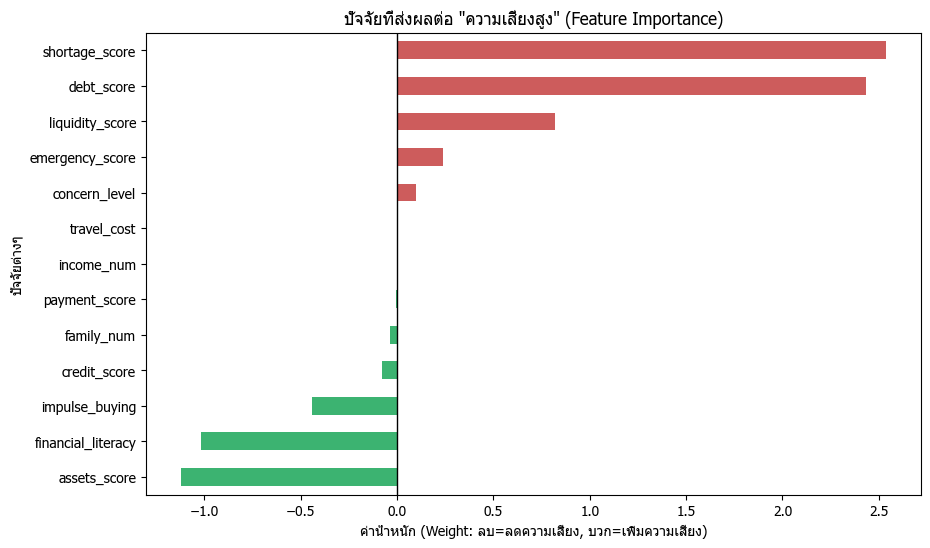

In [60]:
import matplotlib.pyplot as plt
import pandas as pd

# ดึงค่าน้ำหนัก (Coefficients) จากโมเดล Logistic Regression
# เราเลือกดูน้ำหนักของคลาส 'High Risk' (ดัชนี 2 ตามที่เรา encode ไว้: 0=Low, 1=Medium, 2=High)
importance = model_lr.coef_[2]

# การสร้าง DataFrame สำหรับการแสดงผล
feature_imp = pd.DataFrame({'Feature': features, 'Importance': importance})
feature_imp = feature_imp.sort_values(by='Importance', ascending=True)

# พล็อตกราฟ Horizontal Bar Chart
colors = ['mediumseagreen' if x < 0 else 'indianred' for x in feature_imp['Importance']]
feature_imp.plot(kind='barh', x='Feature', y='Importance', color=colors, figsize=(10, 6), legend=False)

plt.title('ปัจจัยที่ส่งผลต่อ "ความเสี่ยงสูง" (Feature Importance)')
plt.xlabel('ค่าน้ำหนัก (Weight: ลบ=ลดความเสี่ยง, บวก=เพิ่มความเสี่ยง)')
plt.ylabel('ปัจจัยต่างๆ')
plt.axvline(x=0, color='black', linewidth=1)
plt.show()

**2. ฟังก์ชันทำนายผลลัพธ์แบบ Hybrid (Live Demo Mock-up)**
ส่วนนี้ตั้งค่าตัวแปรสมมติ (Persona) เอาไว้ หากต้องการทดสอบเคสอื่นๆ สามารถเปลี่ยนตัวเลขในโค้ดแล้วกดรันได้เลย

In [61]:
# ---------- การตั้งค่าข้อมูลส่วนบุคคลจำลอง (Mock Persona) ----------
mock_data = {
    'income_num': [17500],           # รายได้เฉลี่ย (10k-25k)
    'debt_score': [2],               # ภาระหนี้สิน (2 = ร้อยละ 31-50)
    'liquidity_score': [2],          # เงินสำรอง (2 = 1-3 เดือน)
    'shortage_score': [2],           # การหมุนเงินไม่ทัน (2 = 1-2 ครั้งต่อปี)
    'payment_score': [2],            # ชำระบัตรเครดิต (2 = ชำระขั้นต่ำบางส่วน)
    'credit_score': [1],             # จำนวนบัตรเครดิต (1 = 1-2 ใบ)
    'assets_score': [2],             # ทรัพย์สินการลงทุน (2 = มีน้อยกว่า 100% ของรายได้)
    'emergency_score': [2],          # แหล่งเงินฉุกเฉิน (2 = ใช้บัตรเครดิตกู้ยืม)
    'impulse_buying': [4],           # ซื้อของตามใจ (1-5)
    'concern_level': [4],            # ความกังวลทางการเงิน (1-5)
    'financial_literacy': [3],       # ความรู้ด้านการเงิน (1-5)
    'travel_cost': [2000],           # ค่าเดินทาง
    'family_num': [3]                # จำนวนคนในครอบครัว
}
# --------------------------------------------------------------

# การแปลงข้อมูลจำลองเป็นโครงสร้าง DataFrame
user_df = pd.DataFrame(mock_data)

# การประเมินความเสี่ยงด้วยแบบจำลอง Logistic Regression
prediction_code = model_lr.predict(user_df)[0]
probabilities = model_lr.predict_proba(user_df)[0]

# การแปรผลตัวเลขให้เป็นข้อความระดับความเสี่ยง
label_map = {0: 'Low Risk ✅ (เสี่ยงต่ำ)', 1: 'Medium Risk ⚠️ (เสี่ยงปานกลาง)', 2: 'High Risk ❌ (เสี่ยงสูง)'}
advice_map = {
    0: "💡 สถานะการเงินดีเยี่ยม! ควรรักษาวินัยการออมและการลงทุนอย่างต่อเนื่อง",
    1: "💡 ควรเริ่มเพิ่มเงินสำรองฉุกเฉินให้ได้อย่างน้อย 3 เดือน และลดภาระหนี้สินลง",
    2: "💡 อันตราย! ควรหยุดก่อหนี้เพิ่มโดยทันที และรีบหาทางรีไฟแนนซ์หรือลดค่าใช้จ่ายที่ไม่จำเป็น"
}

print("========== ผลการประเมินความเสี่ยง ==========")
print(f"ระดับความเสี่ยงที่ประเมินได้: {label_map[prediction_code]}")
print(f"ระดับความน่าจะเป็น (Probability): {probabilities[prediction_code]*100:.2f}%")
print("-" * 45)
print(f"คำแนะนำ: {advice_map[prediction_code]}")
print("============================================")

========== ผลการประเมินความเสี่ยง ==========
ระดับความเสี่ยงที่ประเมินได้: High Risk ❌ (เสี่ยงสูง)
ระดับความน่าจะเป็น (Probability): 90.99%
---------------------------------------------
คำแนะนำ: 💡 อันตราย! ควรหยุดก่อหนี้เพิ่มโดยทันที และรีบหาทางรีไฟแนนซ์หรือลดค่าใช้จ่ายที่ไม่จำเป็น
